# Decision Tree Classifier

## Tennis as Classifier


In [1]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load the dataset
data = pd.read_csv('DT.csv')

In [3]:
data

,Day,Outlook,Temp,Humidity,Wind,PlayTennis,Unnamed: 6
0,D1,sunny,hot,high,weak,No,NaN
1,D2,sunny,hot,high,strong,No,NaN
2,D3,overcast,hot,high,weak,Yes,NaN
3,D4,rain,mild,high,weak,Yes,NaN
4,D5,rain,cold,normal,weak,Yes,NaN
5,D6,rain,cold,normal,strong,No,NaN
6,D7,overcast,cold,normal,strong,Yes,NaN
7,D8,sunny,mild,high,weak,No,NaN
8,D9,sunny,cold,normal,weak,Yes,NaN
9,D10,rain,mild,normal,weak,Yes,NaN


In [4]:
# Encoding categorical variables
label_encoders = {}
for column in data.columns[1:]: # Ignore 'Day' as it’s an identifier
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le


In [5]:
# Separating features and target variable
X = data[['Outlook', 'Temp', 'Humidity', 'Wind']] # Feature columns
y = data['PlayTennis'] # Target column

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# Train the Decision Tree classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test)

In [8]:
y_pred

array([1, 1, 0])

In [9]:
y_test

9     1
11    1
0     0
Name: PlayTennis, dtype: int64

In [10]:
# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model accuracy:", accuracy)

Model accuracy: 1.0



Confusion Matrix:
[[1 0]
 [0 2]]


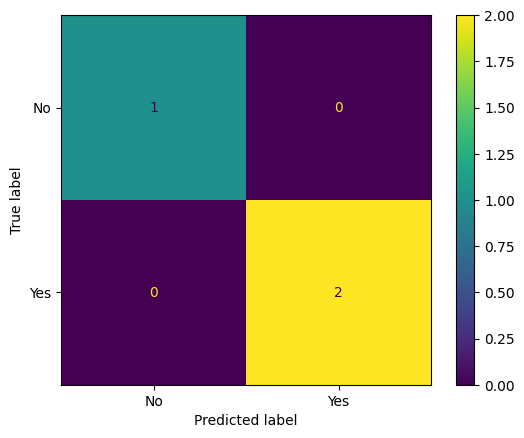

In [11]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_encoders['PlayTennis'].classes_)

In [12]:
# Show actual vs predicted values for each test sample
print("\nActual vs Predicted:")
for actual, predicted in zip(y_test, y_pred):
    print(f"Actual: {label_encoders['PlayTennis'].inverse_transform([actual])[0]}, "f"Predicted: {label_encoders['PlayTennis'].inverse_transform([predicted])[0]}")



Actual vs Predicted:
Actual: Yes, Predicted: Yes
Actual: Yes, Predicted: Yes
Actual: No, Predicted: No


In [13]:
# Example prediction for new input {rain, mild, high, strong}
input_data = pd.DataFrame({
    'Outlook': [label_encoders['Outlook'].transform(['rain'])[0]],
    'Temp': [label_encoders['Temp'].transform(['mild'])[0]],
    'Humidity': [label_encoders['Humidity'].transform(['high'])[0]],
    'Wind': [label_encoders['Wind'].transform(['strong'])[0]]
})


In [14]:
# Predict whether to play tennis
prediction = model.predict(input_data)
result = label_encoders['PlayTennis'].inverse_transform(prediction)
print("\nPrediction for input {rain, mild, high, strong}: Play Tennis =", result[0])



Prediction for input {rain, mild, high, strong}: Play Tennis = No


# Decision tree from Dataset to predict as a Regressor

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
# Load the dataset
data = pd.read_csv('house_data_DT.csv')

In [17]:
 # Ensure all column names are stripped of whitespace
data.columns = data.columns.str.strip()
# Check if 'Location' exists
if 'Location' not in data.columns:
    raise KeyError("'Location' column is missing!")
    
# Convert all values in the 'Location' column to strings and strip whitespace
data['Location'] = data['Location'].astype(str).str.strip()

# Encode the 'Location' column
data['Location'] = data['Location'].map({'Suburb': 0, 'City': 1})

# Check for missing or unmapped values
if data['Location'].isnull().any():
    print("Warning: Some rows in 'Location' have unmapped or invalid values!")
    print(data[data['Location'].isnull()])
    data = data.dropna() # Drop rows with unmapped values if necessary

In [18]:
# Define features (X) and target (y)
X = data[['Rooms', 'Area', 'Location']]
y = data['Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Train the Decision Tree Regressor
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [20]:
# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 2500000000.0
R^2 Score: -10.11111111111111


In [21]:
# Function to predict price based on user input
def predict_price(rooms, area, location):
    # Encode the location input to match training data encoding
    location_encoded = 0 if location.lower() == 'suburb' else 1
    
    # Prepare the input data
    input_data = pd.DataFrame({
    'Rooms': [rooms],
    'Area': [area],
    'Location': [location_encoded]
    })

# Make the prediction
    predicted_price = regressor.predict(input_data)
    print("\nPredicted Price for input (Rooms: {}, Area: {}, Location: {}): ${:,.2f}".format(rooms, area, location, predicted_price[0]))

# Example prediction
predict_price(rooms=3, area=75, location='Suburb')
predict_price(rooms=4, area=95, location='City')



Predicted Price for input (Rooms: 3, Area: 75, Location: Suburb): $320,000.00

Predicted Price for input (Rooms: 4, Area: 95, Location: City): $450,000.00


# Confusion Matrix

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

In [23]:
def plot_confusion_matrix(conf_matrix, class_names):
    df_cm = pd.DataFrame(conf_matrix, index=class_names, columns=class_names)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [24]:
truth = ["Dog","Not a dog","Dog","Dog", "Dog", "Not a dog", "Not a dog", "Dog", "Dog", "Not a dog"]
prediction = ["Dog","Dog", "Dog","Not a dog","Dog", "Not a dog", "Dog", "Not a dog", "Dog", "Dog"]

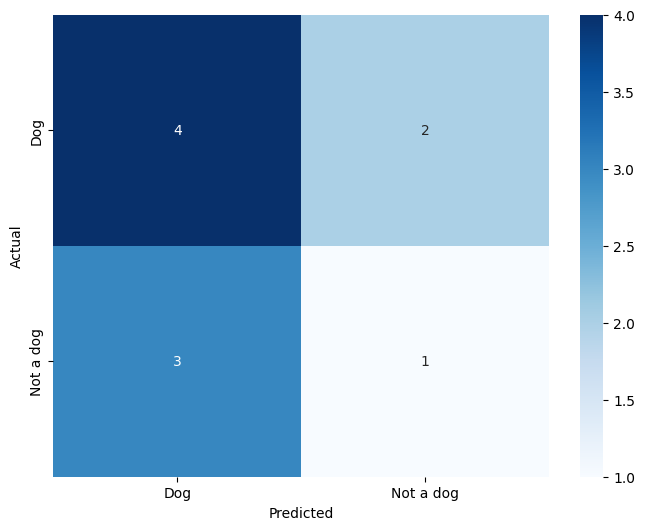

In [25]:
from sklearn.metrics import confusion_matrix
# Assuming 'truth' and 'prediction' are defined earlier in your code
cm = confusion_matrix(truth, prediction)
plot_confusion_matrix(cm, ["Dog", "Not a dog"])

In [26]:
print(classification_report(truth, prediction))

              precision    recall  f1-score   support

         Dog       0.57      0.67      0.62         6
   Not a dog       0.33      0.25      0.29         4

    accuracy                           0.50        10
   macro avg       0.45      0.46      0.45        10
weighted avg       0.48      0.50      0.48        10



##  f1 score for “Dog” class

In [27]:
2*(0.57*0.67/(0.57+0.67))

0.6159677419354839

##  f1 score for “not a Dog” class

In [28]:
2*(0.33*0.25/(0.33+0.25))

0.2844827586206896